# Générateur de Contenu Personnalisé Basé sur l'IA
**Outils :** Python · NumPy · Pandas · Faker · Matplotlib · Seaborn · SciPy

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cosine
from functools import reduce
from faker import Faker

## Partie 1 — Définir les profils et préférences des utilisateurs

In [2]:
# reproductibilité
np.random.seed(42)
Faker.seed(42)

In [15]:
# initialisation de Faker
fake = Faker('fr_FR')

INTERESTS = [
    "fitness", "musique", "technologie", "cuisine", "voyage",
    "cinéma", "lecture", "gaming", "mode", "photographie"
]

# simule le fait que certains intérêts sont plus répandus que d'autres

ALPHA = [3.0, 2.8, 2.2, 1.8, 1.5, 1.3, 1.1, 0.9, 0.7, 0.5]
#         fit  mus  tech cuis  voy  cin  lec  gam  mod  photo
INTEREST_PROBS = stats.dirichlet.rvs(alpha=ALPHA, random_state=42)[0]

print("Probabilités générées par la loi de Dirichlet :")
for interet, prob in zip(INTERESTS, INTEREST_PROBS):
    print(f"  {interet:15} : {prob:.4f}")

ACTIVITY_MAPPING = {
    "fitness": [
        "regardé une vidéo d'entraînement",
        "regardé un tutoriel yoga",
        "regardé une séance HIIT",
        "acheté des protéines en poudre",
        "acheté des bandes de résistance",
        "acheté des chaussures de running",
        "aimé une publication de salle de sport",
        "aimé une photo de transformation",
        "rejoint une salle de sport",
        "complété un défi 30 jours",
        "suivi une course matinale",
        "lu un blog fitness",
        "partagé un conseil nutrition",
    ],
    "musique": [
        "regardé un clip musical",
        "regardé un concert en direct",
        "regardé un tutoriel guitare",
        "acheté des écouteurs",
        "acheté un billet de concert",
        "acheté un vinyle",
        "aimé une chanson",
        "aimé une critique d'album",
        "assisté à un concert",
        "streamé un album",
        "créé une playlist",
        "partagé une recommandation musicale",
        "suivi un artiste",
        "téléchargé un épisode de podcast musical",
    ],
    "technologie": [
        "regardé une conférence sur l'IA",
        "regardé un tutoriel de programmation",
        "regardé une revue de produit tech",
        "lu un blog tech",
        "lu un article de recherche en IA",
        "lu une newsletter développeur",
        "acheté un ordinateur portable",
        "acheté une montre connectée",
        "acheté un clavier mécanique",
        "aimé un article sur l'IA",
        "aimé une publication startup",
        "contribué à l'open source",
        "complété un défi de programmation",
        "étoilé un dépôt GitHub",
        "déployé un projet personnel",
    ],
    "cuisine": [
        "regardé une émission culinaire",
        "regardé un tutoriel recette",
        "regardé un cours de pâtisserie",
        "acheté des ingrédients",
        "acheté un gadget de cuisine",
        "acheté un livre de recettes",
        "aimé une publication de recette",
        "aimé une photo culinaire",
        "essayé une nouvelle recette",
        "préparé les repas de la semaine",
        "visité un marché alimentaire",
        "partagé une recette",
        "suivi un chef",
        "laissé un avis sur un restaurant",
    ],
    "voyage": [
        "regardé un vlog de voyage",
        "regardé un guide de destination",
        "regardé des conseils de bagages",
        "réservé un vol",
        "réservé un hôtel",
        "réservé une visite guidée",
        "acheté une valise",
        "acheté un adaptateur de voyage",
        "acheté une assurance voyage",
        "aimé une photo de voyage",
        "aimé un itinéraire de voyage",
        "enregistré dans un hôtel",
        "laissé un avis sur une attraction",
        "partagé un conseil de voyage",
        "suivi un blogueur voyage",
    ],
    "cinéma": [
        "regardé un film",
        "regardé une bande-annonce",
        "regardé les coulisses d'un film",
        "regardé un documentaire",
        "regardé une analyse cinématographique",
        "acheté un abonnement streaming",
        "acheté un billet de cinéma",
        "noté un film",
        "aimé une critique de film",
        "créé une liste de films à voir",
        "partagé une recommandation de film",
        "suivi un critique de cinéma",
        "assisté à un festival de cinéma",
    ],
    "lecture": [
        "lu un roman",
        "lu un livre de science-fiction",
        "lu une biographie",
        "lu un livre de développement personnel",
        "lu un manga",
        "acheté un ebook",
        "acheté un livre papier",
        "acheté un livre audio",
        "aimé une critique de livre",
        "aimé une liste de lecture",
        "rejoint un club de lecture",
        "partagé une recommandation de livre",
        "suivi un auteur",
        "terminé un défi lecture",
    ],
    "gaming": [
        "regardé un walkthrough de jeu",
        "regardé un tournoi esport",
        "regardé une revue de jeu",
        "acheté un jeu vidéo",
        "acheté un casque gaming",
        "acheté une manette",
        "aimé un clip de jeu",
        "joué en multijoueur",
        "complété le mode histoire",
        "rejoint une communauté gaming",
        "partagé un clip de gameplay",
        "suivi un streamer",
        "participé à un test bêta",
    ],
    "mode": [
        "regardé un défilé de mode",
        "regardé des conseils stylisme",
        "regardé une vidéo haul",
        "acheté des vêtements",
        "acheté des sneakers",
        "acheté des accessoires",
        "aimé une publication tenue",
        "aimé une photo streetwear",
        "suivi un influenceur mode",
        "sauvegardé une inspiration tenue",
        "partagé une tenue du jour",
        "visité une boutique",
        "laissé un avis sur un achat",
    ],
    "photographie": [
        "regardé un tutoriel photo",
        "regardé un walkthrough de retouche",
        "regardé une revue de matériel photo",
        "acheté un objectif",
        "acheté un trépied",
        "acheté un logiciel de retouche",
        "aimé une photo",
        "aimé un conseil photo",
        "retouché une photo sur Lightroom",
        "mis en ligne un portfolio photo",
        "rejoint une communauté photo",
        "partagé un conseil photo",
        "suivi un photographe",
        "participé à un concours photo",
    ],
}


# ── Fonctions utilitaires : conversion chaîne ↔ liste ────────────────────────
def liste_vers_chaine(lst):
    """Convertit une liste ['a', 'b', 'c'] en chaîne 'a,b,c'."""
    return ",".join(lst)

def chaine_vers_liste(s):
    """Convertit une chaîne 'a,b,c' en liste ['a', 'b', 'c'].
    Retourne une liste vide si la valeur est absente."""
    if not isinstance(s, str) or s.strip() == "":
        return []
    return [elt.strip() for elt in s.split(",")]

def generate_user(user_id):
    name = fake.name()
    age = np.random.randint(18, 66)
    num_interests = np.random.randint(1, 4)

    interests_list = [str(x) for x in np.random.choice(
        INTERESTS, size=num_interests, replace=False, p=INTEREST_PROBS
    )]
    interests = liste_vers_chaine(interests_list)
    num_activities = np.random.randint(3, 7)

    activity_log = liste_vers_chaine([
        str(np.random.choice(ACTIVITY_MAPPING[str(np.random.choice(INTERESTS))]))
        for _ in range(num_activities)
    ])
    return {
        "name":         name,
        "age":          age,
        "interests":    interests,    
        "activity_log": activity_log  
    }

def generate_users_dataset(n_users=100):
    users_list = []
    for i in range(n_users):
        user = generate_user(i + 1)
        users_list.append(user)
    df = pd.DataFrame(users_list)
    return df

print('\nEXEMPLE DÉTAILLÉ')
df_users = generate_users_dataset(100)
df_users


Probabilités générées par la loi de Dirichlet :
  fitness         : 0.2303
  musique         : 0.1458
  technologie     : 0.1011
  cuisine         : 0.0776
  voyage          : 0.2481
  cinéma          : 0.1250
  lecture         : 0.0274
  gaming          : 0.0101
  mode            : 0.0290
  photographie    : 0.0055

EXEMPLE DÉTAILLÉ


,name,age,interests,activity_log
0,Claire Bouvier Le Peron,35,musique,"complété un défi 30 jours,acheté un clavier mé..."
1,Noémi Dumont,27,cinéma,"acheté un clavier mécanique,acheté une assuran..."
2,Catherine Julien,58,"fitness,technologie,cinéma","assisté à un concert,regardé une vidéo d'entra..."
3,Nicolas Rivière-Da Costa,46,"mode,musique","rejoint une communauté gaming,acheté un gadget..."
4,Jeanne Blanchard,55,"fitness,musique","aimé une photo,regardé un clip musical,lu un m..."
...,...,...,...,...
95,Michelle Legros,19,voyage,"partagé une recommandation musicale,regardé un..."
96,Sylvie Boulay-Tanguy,28,lecture,"acheté une manette,visité un marché alimentair..."
97,Gérard de Laine,38,"fitness,voyage","suivi un streamer,acheté un adaptateur de voya..."
98,Maryse Garnier,58,"fitness,voyage","regardé un tutoriel photo,essayé une nouvelle ..."


## Partie 2 — Générer et analyser les données

In [4]:
# Génération du dataset brut 
df_brut = generate_users_dataset(500)

df_brut['age'] = df_brut['age'].astype(float)

# certains utilisateurs n'ont pas renseigné leur âge
indices_age_manquant = np.random.choice(500, size=25, replace=False)
df_brut.loc[indices_age_manquant, 'age'] = np.nan

#certains n'ont pas de journal d'activité
indices_log_manquant = np.random.choice(500, size=15, replace=False)
df_brut.loc[indices_log_manquant, 'activity_log'] = None

# Doublons :
doublons = df_brut.sample(n=10, random_state=42)
df_brut = pd.concat([df_brut, doublons], ignore_index=True)

print(f"Dataset brut : {len(df_brut)} lignes")
print(f"Valeurs manquantes :\n{df_brut.isnull().sum()}")

nb_doublons = df_brut.duplicated(subset=['name', 'age', 'interests', 'activity_log']).sum()
print(f"Doublons : {nb_doublons}")

df_brut.to_csv('utilisateurs_brut.csv', index=False)
print("\n dataset exporté vers utilisateurs_brut.csv")


Dataset brut : 510 lignes
Valeurs manquantes :
name             0
age             26
interests        0
activity_log    15
dtype: int64
Doublons : 10

 dataset exporté vers utilisateurs_brut.csv


In [6]:
# chargement depuis le CSV

df_csv = pd.read_csv('utilisateurs_brut.csv')

df = df_csv.drop_duplicates(subset=['name', 'age', 'interests', 'activity_log'])
df = df.dropna(subset=['age', 'activity_log']).reset_index(drop=True)

print(f"Avant nettoyage : {len(df_csv)} lignes")
print(f"Après nettoyage : {len(df)} lignes")
print(f"Valeurs manquantes restantes :\n{df.isnull().sum()}")
df.head()


Avant nettoyage : 510 lignes
Après nettoyage : 461 lignes
Valeurs manquantes restantes :
name            0
age             0
interests       0
activity_log    0
dtype: int64


,name,age,interests,activity_log
0,Adrienne Le Dupré,53.0,voyage,"lu une newsletter développeur,aimé une chanson..."
1,Daniel Aubry,64.0,"voyage,fitness,cuisine","assisté à un concert,regardé un walkthrough de..."
2,Bernard Bernier,26.0,technologie,"rejoint une communauté gaming,aimé une publica..."
3,Colette Maillard-Carre,54.0,"musique,voyage,fitness","partagé un conseil nutrition,complété un défi ..."
4,Françoise Wagner Le Martins,25.0,"cinéma,voyage,cuisine","assisté à un concert,retouché une photo sur Li..."


In [7]:

tous_interets = [interet for s in df['interests'] for interet in chaine_vers_liste(s)]
freq_interets = pd.Series(tous_interets).value_counts()
print("Fréquence des intérêts :")
print(freq_interets)


Fréquence des intérêts :
voyage          200
fitness         198
musique         135
cinéma          119
technologie     110
cuisine          83
lecture          31
mode             28
photographie     11
gaming           10
Name: count, dtype: int64


In [8]:
# Test χ² — la distribution observée correspond-elle aux probabilités Dirichlet ?
# Fréquences observées dans l'ordre de INTERESTS
observees = [freq_interets.get(i, 0) for i in INTERESTS]

# Fréquences théoriques basées sur les probabilités Dirichlet
total = sum(observees)
attendues = [total * p for p in INTEREST_PROBS]
attendues_int = [int(round(x)) for x in attendues]
# Ajustement pour que la somme soit exacte
attendues_int[-1] += total - sum(attendues_int)

print("Observé vs Attendu (Dirichlet) :")
for interet, obs, att in zip(INTERESTS, observees, attendues_int):
    print(f"  {interet:15} : observé={obs:3}  attendu={att:3}")


print("Hypothèse 0 : La distribution observée est conforme aux probabilités Dirichlet attendues.")
chi2, p_valeur = stats.chisquare(observees, attendues_int)
print(f"\n Test χ² — distribution des intérêts : χ²={chi2:.2f}, p={p_valeur:.4f}")
if p_valeur < 0.05:
    print('→ Distribution NON uniforme : certains intérêts sont significativement plus populaires')
else:
    print('→ Distribution conforme aux probabilités Dirichlet attendues')


Observé vs Attendu (Dirichlet) :
  fitness         : observé=198  attendu=213
  musique         : observé=135  attendu=135
  technologie     : observé=110  attendu= 94
  cuisine         : observé= 83  attendu= 72
  voyage          : observé=200  attendu=230
  cinéma          : observé=119  attendu=116
  lecture         : observé= 31  attendu= 25
  gaming          : observé= 10  attendu=  9
  mode            : observé= 28  attendu= 27
  photographie    : observé= 11  attendu=  4
Hypothèse 0 : La distribution observée est conforme aux probabilités Dirichlet attendues.

 Test χ² — distribution des intérêts : χ²=23.29, p=0.0056
→ Distribution NON uniforme : certains intérêts sont significativement plus populaires


In [9]:
# Test χ² de contingence
# Question : regarder du contenu IA corrèle-t-il avec acheter un ordinateur portable ?
df['a_vu_ia']          = df['activity_log'].apply(lambda s: 1 if "regardé une conférence sur l'IA" in chaine_vers_liste(s) else 0)
df['a_achete_ordi']    = df['activity_log'].apply(lambda s: 1 if 'acheté un ordinateur portable' in chaine_vers_liste(s) else 0)
tableau = pd.crosstab(df['a_vu_ia'], df['a_achete_ordi'])
print("H0: Il y a indépendance entre la variable a_vu_ia et la variable a_achete_ordi")
chi2_c, p_v, _ , _ = stats.chi2_contingency(tableau)
print(f"Test χ² de contingence : χ²={chi2_c:.2f}, p={p_v:.4f}")
if p_v < 0.05:
    print('→ Relation statistiquement significative')
else:
    print('→ Aucune relation significative entre ces deux actions')


display(tableau)

H0: Il y a indépendance entre la variable a_vu_ia et la variable a_achete_ordi
Test χ² de contingence : χ²=0.00, p=1.0000
→ Aucune relation significative entre ces deux actions


a_achete_ordi,0,1
a_vu_ia,,
0,432,14
1,15,0


## Partie 3 — Moteur de recommandation
Utilisation de la **POO**, des fonctions **lambda**, **map**, **filter**, **reduce**
et de la **similarité cosinus** (`scipy.spatial.distance`) pour comparer les profils.

In [16]:
# Catalogue de recommandations associé à chaque intérêt
RECOMMANDATIONS_PAR_INTERET = {
    "fitness":        ["Programme HIIT 30 min", "Plan nutrition semaine", "Guide musculation maison", "Défi 30 jours abdos"],
    "musique":        ["Playlist Rock 2024", "Top Jazz lo-fi", "Cours guitare en ligne", "Podcast histoire de la musique"],
    "technologie":    ["Blog IA du MIT", "Cours Python avancé", "Guide débutant open source", "Newsletter tech hebdomadaire"],
    "cuisine":        ["Recettes végétariennes rapides", "Meal prep de la semaine", "Cours pâtisserie en ligne", "Guide épices et assaisonnements"],
    "voyage":         ["Top destinations 2024", "Guide voyage en solo", "Astuces bagages cabine", "Road trips en Europe"],
    "cinéma":         ["Top films Netflix ce mois", "Documentaires tendance", "Top thrillers psychologiques", "Rétrospective Spielberg"],
    "lecture":        ["Top romans 2024", "Sélection science-fiction", "Top biographies inspirantes", "Podcast littéraire hebdomadaire"],
    "gaming":         ["Top jeux 2024", "Sélection jeux indépendants", "Top jeux coopératifs", "Guide configuration PC gaming"],
    "mode":           ["Tendances mode printemps 2024", "Guide sneakers 2024", "Lookbook minimaliste", "Top vintage et seconde main"],
    "photographie":   ["Cours photo débutant", "Tutoriel Lightroom", "Guide composition et cadrage", "Top appareils photo 2024"],
}


In [17]:
class ProfilUtilisateur:
    """Classe de base représentant un profil utilisateur (encapsulation).
    Les attributs interests et activity_log sont stockés en chaîne 'elt1,elt2,...'
    et exposés en liste via des propriétés."""

    def __init__(self, name, age, interests, activity_log):
        # Attributs privés — encapsulation
        self.__name         = name
        self.__age          = age
        # Accepte liste ou chaîne en entrée, stocke toujours en chaîne
        self.__interests    = liste_vers_chaine(interests)    if isinstance(interests, list)    else interests
        self.__activity_log = liste_vers_chaine(activity_log) if isinstance(activity_log, list) else activity_log

    @property
    def name(self):         return self.__name
    @property
    def age(self):          return self.__age
    @property
    def interests(self):    return chaine_vers_liste(self.__interests)
    @property
    def activity_log(self): return chaine_vers_liste(self.__activity_log)

    def __repr__(self):
        return f"ProfilUtilisateur(name={self.__name}, age={self.__age}, interests={self.interests})"

    
    def vecteur_interets(self):
        v_interests = np.array([1.0 if i in self.interests else 0.0 for i in INTERESTS])
        v_actions = np.zeros(len(INTERESTS))
        for idx, interet in enumerate(INTERESTS):
            actions_interet = ACTIVITY_MAPPING.get(interet, [])
            v_actions[idx] = sum(1 for a in self.activity_log if a in actions_interet)
        return v_interests + v_actions

    def description(self):
        """Méthode polymorphique : décrit le profil (redéfinie dans les sous-classes)."""
        return f"Utilisateur standard : {self.__name}, {self.__age} ans"


class ProfilPremium(ProfilUtilisateur):
    """Sous-classe héritant de ProfilUtilisateur — utilisateur premium (héritage)."""

    def __init__(self, name, age, interests, activity_log, niveau='gold'):
        super().__init__(name, age, interests, activity_log)
        self.niveau = niveau

    def description(self):
        """Polymorphisme : redéfinition de description()."""
        return f"Utilisateur premium ({self.niveau}) : {self.name}, {self.age} ans"


class MoteurRecommandation:
    """Moteur de recommandation personnalisé basé sur les intérêts et profils similaires."""

    def __init__(self, df):
        self.profils = [
            ProfilUtilisateur(row['name'], row['age'], row['interests'], row['activity_log'])  
            for _, row in df.iterrows()
        ]
        # Top 10 des contenus les plus populaires (utilisé quand aucun intérêt)
        self.top10_populaires = self._calculer_top10(df)

    def _calculer_top10(self, df):
        tous_interets = [i for s in df['interests'] for i in chaine_vers_liste(str(s)) if i]
        freq = pd.Series(tous_interets).value_counts()
        populaires = []
        for interet in freq.index.tolist():
            if interet in RECOMMANDATIONS_PAR_INTERET:
                populaires.extend(RECOMMANDATIONS_PAR_INTERET[interet][:2])
            if len(populaires) >= 10:
                break
        return populaires[:10]

    def trouver_utilisateurs_similaires(self, profil, top_n=5):
        """Similarité cosinus pour identifier les profils les plus proches."""
        vecteur_cible = profil.vecteur_interets()
        # Si le vecteur cible est nul, impossible de calculer la similarité cosinus
        if not np.any(vecteur_cible):
            return []
        similarites = []
        for autre in self.profils:
            if autre.name == profil.name:
                continue
            vecteur_autre = autre.vecteur_interets()
            if not np.any(vecteur_autre):
                continue
            score = 1 - cosine(vecteur_cible, vecteur_autre)
            # Ignorer les nan (division par zéro dans cosine)
            if np.isnan(score):
                continue
            similarites.append((autre, round(score, 3)))
        similarites.sort(key=lambda x: x[1], reverse=True)
        return similarites[:top_n]

    def recommander(self, profil):
        """Génère des suggestions basées sur :
        1. Les intérêts et activités de l'utilisateur (filter/map/reduce)
        2. Les comportements des utilisateurs similaires (filtrage collaboratif)
        Si aucun intérêt renseigné → top 10 des contenus les plus populaires.
        """
        # Cas sans intérêts : retourner le top 10 populaire
        if not profil.interests:
            return {
                'suggestions_personnelles':   [],
                'suggestions_collaboratives': [],
                'utilisateurs_similaires':    [],
                'top10_populaires':           self.top10_populaires,
            }

        # ── Recommandations personnelles ──────────────────────────────────
        # filter : intérêts présents dans le catalogue
        interets_valides = list(filter(lambda i: i in RECOMMANDATIONS_PAR_INTERET, profil.interests))
        # map : récupère les recommandations pour chaque intérêt
        listes_reco = list(map(lambda i: RECOMMANDATIONS_PAR_INTERET[i], interets_valides))
        # reduce : fusionne toutes les listes
        recos_perso = reduce(lambda a, b: a + b, listes_reco) if listes_reco else []

        

        # ── Recommandations collaboratives ────────────────────────────────
        similaires = self.trouver_utilisateurs_similaires(profil, top_n=5)
        recos_collaboratives = []
        if similaires:
            # Score via intérêts déclarés + activités non faites par le profil cible
            score_interets = {}
            actions_cible  = set(profil.activity_log)
            for autre_profil, sim_score in similaires:
                for interet in autre_profil.interests:
                    score_interets[interet] = score_interets.get(interet, 0) + sim_score * 2
                for action in autre_profil.activity_log:
                    if action in actions_cible:
                        continue
                    for interet, actions in ACTIVITY_MAPPING.items():
                        if action in actions:
                            score_interets[interet] = score_interets.get(interet, 0) + sim_score
                            break

            interets_tries = sorted(score_interets.items(), key=lambda x: x[1], reverse=True)
            deja_recommandes = set(recos_perso)
            for interet, _ in interets_tries:
                if interet in RECOMMANDATIONS_PAR_INTERET:
                    nouveaux = [r for r in RECOMMANDATIONS_PAR_INTERET[interet] if r not in deja_recommandes]
                    recos_collaboratives.extend(nouveaux[:2])
                    deja_recommandes.update(nouveaux[:2])
                if len(recos_collaboratives) >= 6:
                    break
            # Fallback si toujours vide : top populaire global
            if not recos_collaboratives:
                recos_collaboratives = [r for r in self.top10_populaires if r not in set(recos_perso)][:6]

        return {
            'suggestions_personnelles':    recos_perso,
            'suggestions_collaboratives':  recos_collaboratives,
            'utilisateurs_similaires':     [(p.name, s) for p, s in similaires[:3]],
            'top10_populaires':            [],   
        }

    def afficher_recommandations(self, nom_utilisateur):
        """Affiche toutes les recommandations pour un utilisateur donné."""
        profil = next((p for p in self.profils if p.name == nom_utilisateur), None)
        if profil is None:
            print(f"Utilisateur '{nom_utilisateur}' introuvable.")
            return
        recos = self.recommander(profil)
        print(f"\n{'='*55}")
        print(f"RECOMMANDATIONS POUR : {profil.name}")
        print(f"{'='*55}")
        print(f"Âge : {profil.age} | Intérêts : {profil.interests}")
        print(f"Journal d'activité : {profil.activity_log}")

        print('\n🎯 Suggestions personnalisées (basées sur vos intérêts) :')
        for r in recos['suggestions_personnelles']:
            print(f'  • {r}')

        if recos['suggestions_collaboratives']:
            print('\n👥 Découvertes collaboratives (basées sur profils similaires) :')
            for r in recos['suggestions_collaboratives']:
                print(f'  • {r}')

        
        print('\n🔗 Utilisateurs avec des goûts similaires :')
        for nom, score in recos['utilisateurs_similaires']:
            print(f'  → {nom} (similarité : {score})')

        # Démonstration du polymorphisme
        premium = ProfilPremium(profil.name, profil.age, profil.interests, profil.activity_log)
        print(f'\n  [{premium.description()}]')


# Test d'instanciation
print("ProfilUtilisateur :", ProfilUtilisateur('Test', 30, ['fitness'], []))
print("ProfilPremium     :", ProfilPremium('Test', 30, ['fitness'], []).description())


ProfilUtilisateur : ProfilUtilisateur(name=Test, age=30, interests=['fitness'])
ProfilPremium     : Utilisateur premium (gold) : Test, 30 ans


In [13]:
# Instanciation du moteur et test sur deux utilisateurs
moteur = MoteurRecommandation(df)
# Récupération de deux noms réels du dataset nettoyé
nom1 = "Simone Legros Le Fabre"

moteur.afficher_recommandations(nom1)



RECOMMANDATIONS POUR : Simone Legros Le Fabre
Âge : 47.0 | Intérêts : ['musique', 'voyage']
Journal d'activité : ['regardé un tutoriel recette', 'acheté un trépied', 'suivi un auteur', 'complété un défi 30 jours', 'aimé une photo', 'suivi un photographe']

🎯 Suggestions personnalisées (basées sur vos intérêts) :
  • Playlist Rock 2024
  • Top Jazz lo-fi
  • Cours guitare en ligne
  • Podcast histoire de la musique
  • Top destinations 2024
  • Guide voyage en solo
  • Astuces bagages cabine
  • Road trips en Europe

👥 Découvertes collaboratives (basées sur profils similaires) :
  • Cours photo débutant
  • Tutoriel Lightroom
  • Programme HIIT 30 min
  • Plan nutrition semaine
  • Top romans 2024
  • Sélection science-fiction

🔗 Utilisateurs avec des goûts similaires :
  → Joséphine Besson (similarité : 0.953)
  → Jules Lenoir (similarité : 0.93)
  → Sabine Fontaine de la Mercier (similarité : 0.921)

  [Utilisateur premium (gold) : Simone Legros Le Fabre, 47.0 ans]


## Partie 4 — Visualiser les informations
Utilisation de **Matplotlib** et **Seaborn** pour :
- La répartition des intérêts
- La heatmap d'intensité d'activité par catégorie
- Les catégories recommandées par segment d'utilisateurs

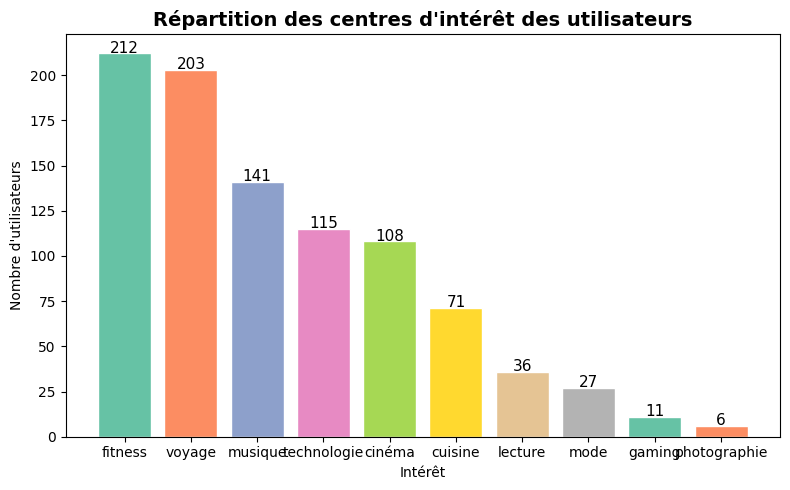

In [50]:
# Graphique 1 — Répartition des centres d'intérêt des utilisateurs
fig, ax = plt.subplots(figsize=(8, 5))
couleurs = sns.color_palette('Set2', len(freq_interets))
ax.bar(freq_interets.index, freq_interets.values, color=couleurs, edgecolor='white')
ax.set_title("Répartition des centres d'intérêt des utilisateurs", fontsize=14, fontweight='bold')
ax.set_xlabel('Intérêt')
ax.set_ylabel("Nombre d'utilisateurs")
for i, v in enumerate(freq_interets.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

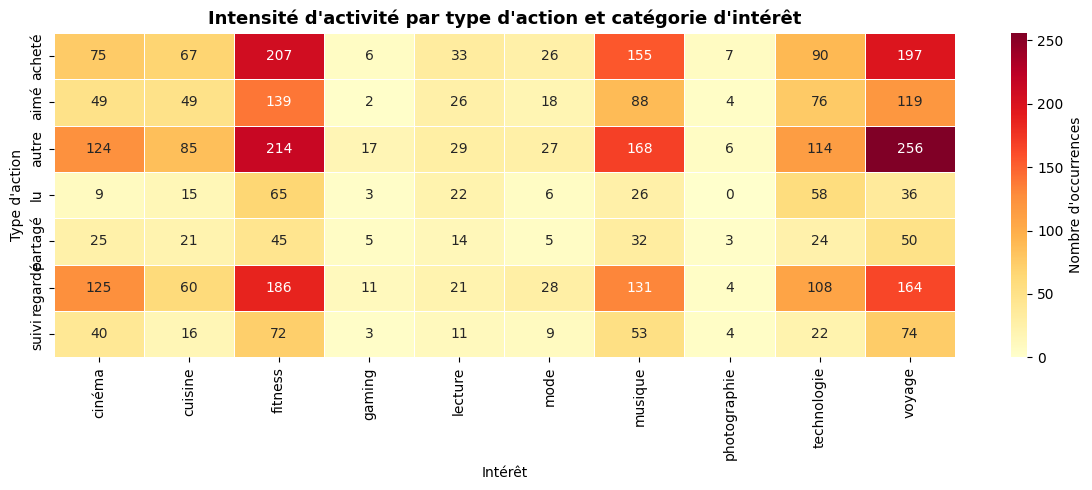

In [51]:
# Graphique 2 — Heatmap d'intensité d'activité par type d'action et intérêt

def detecter_type_action(action):
    """Détecte le type d'action à partir du verbe en français."""
    if action.startswith('regardé'):   return 'regardé'
    if action.startswith('acheté'):    return 'acheté'
    if action.startswith('aimé'):      return 'aimé'
    if action.startswith('lu'):        return 'lu'
    if action.startswith('partagé'):   return 'partagé'
    if action.startswith('suivi'):     return 'suivi'
    return 'autre'

lignes = []
for _, row in df.iterrows():
    for interet in chaine_vers_liste(row['interests']):
        for action in chaine_vers_liste(row['activity_log']):
            lignes.append({'interet': interet, 'type_action': detecter_type_action(action)})

df_heatmap = pd.DataFrame(lignes)
matrice = df_heatmap.groupby(['type_action', 'interet']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(matrice, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': "Nombre d'occurrences"})
ax.set_title("Intensité d'activité par type d'action et catégorie d'intérêt", fontsize=13, fontweight='bold')
ax.set_xlabel('Intérêt')
ax.set_ylabel("Type d'action")
plt.tight_layout()
plt.show()


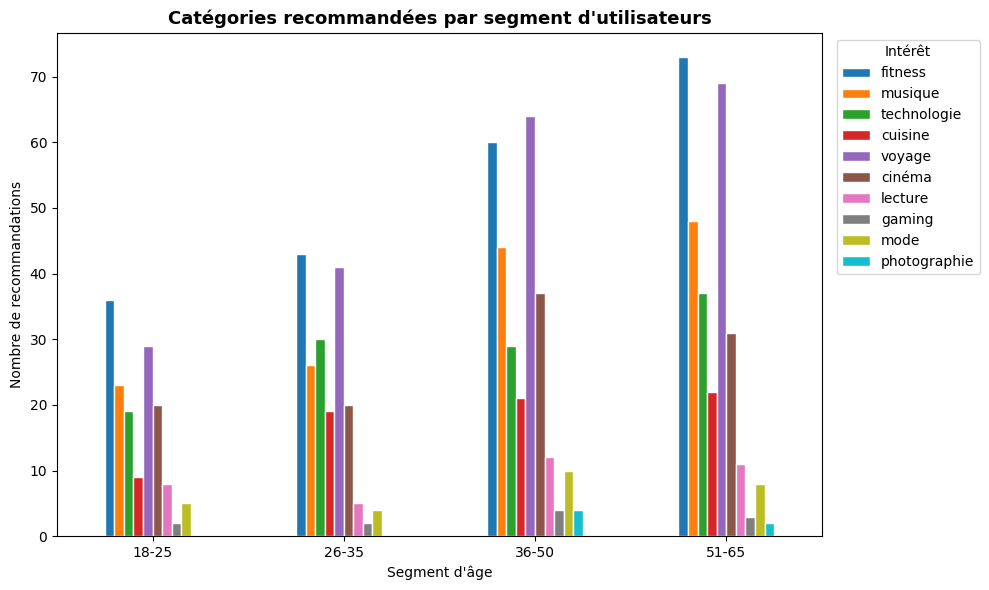

In [52]:
# Graphique 3 — Catégories recommandées par segment d'utilisateurs
df_seg = df.copy()
df_seg['segment'] = pd.cut(df_seg['age'], bins=[17, 25, 35, 50, 65],
                            labels=['18-25', '26-35', '36-50', '51-65'])

comptage = {seg: {i: 0 for i in INTERESTS} for seg in ['18-25', '26-35', '36-50', '51-65']}
for _, row in df_seg.iterrows():
    seg = str(row['segment'])
    if seg == 'nan':
        continue
    for interet in chaine_vers_liste(row['interests']):
        if interet in comptage[seg]:
            comptage[seg][interet] += 1

df_plot = pd.DataFrame(comptage).T
df_plot.index.name = "Segment d'âge"

fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Catégories recommandées par segment d'utilisateurs", fontsize=13, fontweight='bold')
ax.set_xlabel("Segment d'âge")
ax.set_ylabel('Nombre de recommandations')
ax.legend(title='Intérêt', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Graphique 4 (Bonus) — Heatmap : Intensité d'activité par heure et catégorie

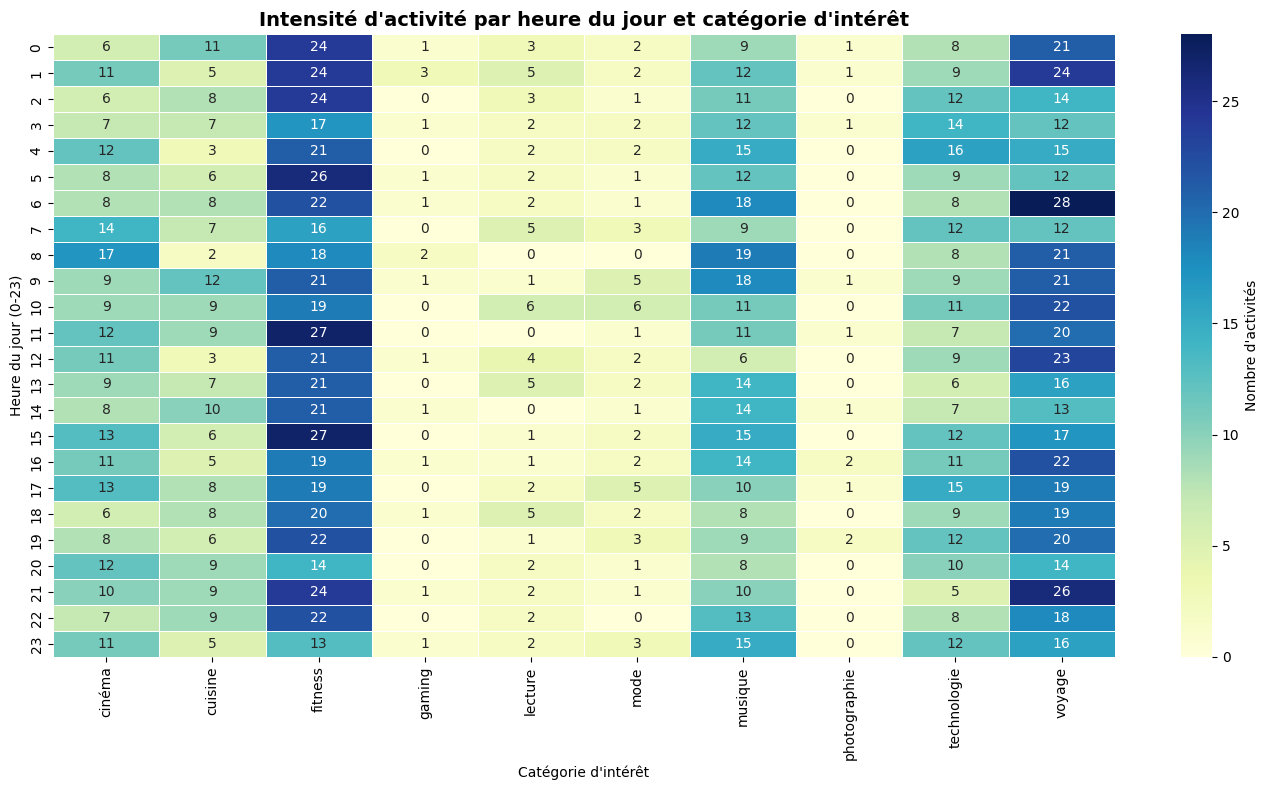


Statistiques d'activité par heure :
Heures de pointe : [9, 1, 6]
Heures creuses   : [20, 3, 14]


In [53]:
# Génération des enregistrements d'activité avec horodatage
activity_records = []
for _, row in df.iterrows():
    for action in chaine_vers_liste(row['activity_log']):
        heure = np.random.randint(0, 24)
        # Déterminer l'intérêt associé à l'action
        interet_associe = chaine_vers_liste(row['interests'])[0]
        for interet in chaine_vers_liste(row['interests']):
            if interet in ACTIVITY_MAPPING and action in ACTIVITY_MAPPING[interet]:
                interet_associe = interet
                break
        activity_records.append({'heure': heure, 'interet': interet_associe, 'action': action})

df_activity = pd.DataFrame(activity_records)

# Matrice heure × intérêt
matrice_heure = df_activity.groupby(['heure', 'interet']).size().unstack(fill_value=0)

# Heatmap par heure et catégorie d'intérêt
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(matrice_heure, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': "Nombre d'activités"})
ax.set_title("Intensité d'activité par heure du jour et catégorie d'intérêt", fontsize=14, fontweight='bold')
ax.set_xlabel("Catégorie d'intérêt")
ax.set_ylabel('Heure du jour (0-23)')
plt.tight_layout()
plt.show()

print("\nStatistiques d'activité par heure :")
print(f"Heures de pointe : {matrice_heure.sum(axis=1).nlargest(3).index.tolist()}")
print(f"Heures creuses   : {matrice_heure.sum(axis=1).nsmallest(3).index.tolist()}")


In [ ]:
## Partie 5 — Ajouter un nouvel utilisateur et générer ses recommandations

def ajouter_utilisateur(moteur, df, name, age, interests, activity_log):
    """
    Ajoute un nouvel utilisateur au dataset et au moteur,
    puis affiche ses recommandations personnalisées.
    """
    # Vérification des intérêts saisis
    interets_valides = [i for i in interests if i in INTERESTS]
    # Pas de blocage si aucun intérêt : on affichera le top 10 populaire

    # Création du profil
    nouveau_profil = ProfilUtilisateur(name, age, interets_valides, activity_log)

    # Ajout au moteur
    moteur.profils.append(nouveau_profil)

    # Ajout au DataFrame
    nouvelle_ligne = pd.DataFrame([{
        'name':         name,
        'age':          float(age),
        'interests':    liste_vers_chaine(interets_valides),
        'activity_log': liste_vers_chaine(activity_log)
    }])
    df = pd.concat([df, nouvelle_ligne], ignore_index=True)

    print(f"✅ Utilisateur '{name}' ajouté avec succès.")

    # Affichage des recommandations
    recos = moteur.recommander(nouveau_profil)

    print(f"\n{'='*55}")
    print(f"RECOMMANDATIONS POUR : {name}")
    print(f"{'='*55}")
    print(f"Âge : {age} | Intérêts : {interets_valides}")
    print(f"Journal d'activité : {activity_log}")

    # Cas sans intérêts : afficher le top 10 populaire
    if recos['top10_populaires']:
        print('\nℹ️  Aucun intérêt renseigné — Top 10 des contenus les plus populaires :')
        for r in recos['top10_populaires']:
            print(f'  • {r}')
    else:
        print('\n🎯 Suggestions personnalisées (basées sur vos intérêts) :')
        for r in recos['suggestions_personnelles']:
            print(f'  • {r}')

        if recos['suggestions_collaboratives']:
            print('\n👥 Découvertes collaboratives (basées sur profils similaires) :')
            for r in recos['suggestions_collaboratives']:
                print(f'  • {r}')

      

        print('\n🔗 Utilisateurs avec des goûts similaires :')
        for nom, score in recos['utilisateurs_similaires']:
            print(f'  → {nom} (similarité : {score})')

    return moteur, df


# Exemple d'ajout d'un nouvel utilisateur
moteur, df = ajouter_utilisateur(
    moteur, df,
    name         = "Kouassi Akré",
    age          = 24,
    interests    = ["technologie", "gaming"],
    activity_log = [
        "regardé une conférence sur l'IA",
        "acheté un ordinateur portable",
        "joué en multijoueur",
        "regardé un tutoriel de programmation"
    ]
)
